In [3]:
import os
from importlib.util import find_spec
from IPython import get_ipython

IN_VSCODE = bool(os.environ.get('VSCODE_PID'))
if IN_VSCODE:
    PREFERRED_MATPLOTLIB_BACKENDS = [('widget', 'module://ipympl.backend_nbagg'), ('qt', 'qt'), ('notebook', 'notebook')]
else:
    PREFERRED_MATPLOTLIB_BACKENDS = [('widget', 'module://ipympl.backend_nbagg'), ('notebook', 'notebook'), ('qt', 'qt')]
ip = get_ipython()
if IN_VSCODE:
    print('VS Code detected; trying %matplotlib widget first, then falling back to qt/notebook if needed')


VS Code detected; trying %matplotlib widget first, then falling back to qt/notebook if needed


In [4]:

for MATPLOTLIB_BACKEND, MATPLOTLIB_MAGIC_ARG in PREFERRED_MATPLOTLIB_BACKENDS:
    if MATPLOTLIB_BACKEND == 'widget' and find_spec('ipympl') is None:
        print("ipympl is not installed; skipping %matplotlib widget")
        continue
    try:
        if MATPLOTLIB_BACKEND == 'widget':
            import ipympl
        ip.run_line_magic('matplotlib', MATPLOTLIB_MAGIC_ARG)
        print(f"Using %matplotlib {MATPLOTLIB_BACKEND}")
        break
    except Exception as exc:
        print(f"Failed to enable %matplotlib {MATPLOTLIB_BACKEND}: {exc}")
else:
    MATPLOTLIB_BACKEND = 'inline'
    ip.run_line_magic('matplotlib', MATPLOTLIB_BACKEND)
    print("Falling back to %matplotlib inline")

import sys
print(sys.executable)
print(sys.version)
import matplotlib
print(matplotlib.get_backend())

%matplotlib widget


Using %matplotlib widget
c:\Users\One\AppData\Local\Programs\Python\Python312\python.exe
3.12.10 (tags/v3.12.10:0cc8128, Apr  8 2025, 12:21:36) [MSC v.1943 64 bit (AMD64)]
module://ipympl.backend_nbagg


In [5]:
from getgrid import getgrid
from pathlib import Path
from data_paths import grid_dir
_, _, _, z, _, _, _ = getgrid(base_dir=Path(grid_dir))

In [6]:
from pathlib import Path

from data_paths import AW_DIR, BIOEXP

import importlib
import numpy as np
import phyto_sibciom
import vert_profile

importlib.reload(vert_profile)
importlib.reload(phyto_sibciom)

from phyto_sibciom import (
    compute_shared_color_limits,
    inspect_nc,
    make_file_path,
    plot_field_from_click,
    plot_linked_fields_from_click,
    prepare_sibciom_3dvar,
)
from vert_profile import compute_aw_fields, convert_aw_units, prepare_aw_3dvar

# Observed field parameters
AW_MODE = 'mmol'  # cells = cells/m3; mmol = mmolC/m3 or mmolN/m3
MMOL_BASIS = 'C'  # Used only when AW_MODE == 'mmol': C or N
#    формула перевода: Aw_mmolC = Aw_cells * mg_c_per_cell / mg_c_per_mmol_c

AW_MG_C_PER_CELL = 2726e-9  # Conversion from cells to mg C per cell
MG_C_PER_MMOL_C = 12.011  # Mass of 1 mmol of carbon in mg C
N_PER_C_MOLAR = 16.0 / 106.0  # Molar N/C ratio 
AW_YEAR = 2017   
MONTH = 8  
AW_DAY = 10  
LIGHT_SCHEME = 'jerlov_two_component'  # 'beer_chl' or 'jerlov_two_component'
JERLOV_TYPE = 1  # Jerlov water type from forcing.F table
JERLOV_P = None  # Override component weight; None uses table value
JERLOV_LAMBDA1 = None  # Override fast attenuation coefficient
JERLOV_LAMBDA2 = None  # Override slow attenuation coefficient
JERLOV_LAMBDA_UNITS = 'cm^-1'  # Forcing.F coefficients are in cm^-1
LEVEL = 3  # Vertical level index for 2d-maps
NLEV = 12  # Number of profile levels.  None means all levels
INITIAL_I = 118  
INITIAL_J = 107  

# SibCIOM parameters
DATA_DIR = BIOEXP  # Directory with monthly model NetCDF files
VAR_NAME = 'phyto'   # Model variable to plot
SNAP_YEAR = 2017  #
SNAP_MONTH = MONTH  
NC_INFO = False  # Print NetCDF structure before plotting


In [7]:
result = compute_aw_fields(
    year=AW_YEAR,
    month=MONTH,
    day=AW_DAY,
    base_dir=AW_DIR,
    light_scheme=LIGHT_SCHEME,
    jerlov_type=JERLOV_TYPE,
    jerlov_p=JERLOV_P,
    jerlov_lambda1=JERLOV_LAMBDA1,
    jerlov_lambda2=JERLOV_LAMBDA2,
    jerlov_lambda_units=JERLOV_LAMBDA_UNITS,
)
obs_field = result['Aw']  # replace 'Aw' with 'chl' or 'Iz' if needed
# obs_field =  result['chl']

FileNotFoundError: Не найден файл: \media\dina\data4tb\Chl_Marina\grid2.dat

In [ ]:

if obs_field['field_key'] == 'Aw': 
    obs_field = convert_aw_units(
        obs_field,
        mode=AW_MODE,
        mmol_basis=MMOL_BASIS,
        mg_c_per_cell=AW_MG_C_PER_CELL,
        mg_c_per_mmol_c=MG_C_PER_MMOL_C,
        n_per_c_molar=N_PER_C_MOLAR,
    )

obs = prepare_aw_3dvar(obs_field)

phyto = prepare_sibciom_3dvar(
    data_dir=DATA_DIR,
    year=SNAP_YEAR,
    month=SNAP_MONTH,
    var_name=VAR_NAME,
    grid_base_dir=AW_DIR,
)

common_vmin, common_vmax = compute_shared_color_limits(
    np.asarray(obs['var_3d'])[:, :, LEVEL],
    np.asarray(phyto['var_3d'])[:, :, LEVEL],
)
common_vmin, common_vmax = 0, 4
plot_common_kwargs = {
    'map_level': LEVEL,
    'profile_nlev': NLEV,
    'map_vmin': common_vmin,
    'map_vmax': common_vmax,
}

def prefix_kwargs(prefix, kwargs):
    return {f'{prefix}{key}': value for key, value in kwargs.items()}

obs_field_kwargs = {
    'var': np.asarray(obs['var_3d']),
    'z_levels': np.asarray(obs['levels']),
    'year': AW_YEAR,
    'month': MONTH,
    'var_name': str(obs['var_name']),
    'var_units': str(obs['var_units']),
}

phyto_field_kwargs = {
    'var': np.asarray(phyto['var_3d']),
    'z_levels': np.asarray(phyto['levels']),
    'year': SNAP_YEAR,
    'month': SNAP_MONTH,
    'var_name': VAR_NAME,
    'var_units': str(phyto['units']),
}


In [ ]:
INITIAL_I=250
INITIAL_J=300
INITIAL_I,INITIAL_J

(250, 300)

In [ ]:

if obs_field['field_key'] == 'Aw': 
    obs_field = convert_aw_units(
        obs_field,
        mode=AW_MODE,
        mmol_basis=MMOL_BASIS,
        mg_c_per_cell=AW_MG_C_PER_CELL,
        mg_c_per_mmol_c=MG_C_PER_MMOL_C,
        n_per_c_molar=N_PER_C_MOLAR,
    )

obs = prepare_aw_3dvar(obs_field)

phyto = prepare_sibciom_3dvar(
    data_dir=DATA_DIR,
    year=SNAP_YEAR,
    month=SNAP_MONTH,
    var_name=VAR_NAME,
    grid_base_dir=AW_DIR,
)

common_vmin, common_vmax = compute_shared_color_limits(
    np.asarray(obs['var_3d'])[:, :, LEVEL],
    np.asarray(phyto['var_3d'])[:, :, LEVEL],
)
common_vmin, common_vmax = 0, 4
plot_common_kwargs = {
    'map_level': LEVEL,
    'profile_nlev': NLEV,
    'map_vmin': common_vmin,
    'map_vmax': common_vmax,
}

def prefix_kwargs(prefix, kwargs):
    return {f'{prefix}{key}': value for key, value in kwargs.items()}

obs_field_kwargs = {
    'var': np.asarray(obs['var_3d']),
    'z_levels': np.asarray(obs['levels']),
    'year': AW_YEAR,
    'month': MONTH,
    'var_name': str(obs['var_name']),
    'var_units': str(obs['var_units']),
}

phyto_field_kwargs = {
    'var': np.asarray(phyto['var_3d']),
    'z_levels': np.asarray(phyto['levels']),
    'year': SNAP_YEAR,
    'month': SNAP_MONTH,
    'var_name': VAR_NAME,
    'var_units': str(phyto['units']),
}


In [ ]:
# selected_file = make_file_path(BIOEXP, SNAP_YEAR, SNAP_MONTH)
# print(f'Selected file: {selected_file}')
# if NC_INFO:
#     inspect_nc(selected_file)

# obs_i, obs_j = plot_field_from_click(
#     i=INITIAL_I,
#     j=INITIAL_J,
#     **obs_field_kwargs,
#     **plot_common_kwargs,
# )

# phyto_i, phyto_j = plot_field_from_click(
#     i=obs_i,
#     j=obs_j,
#     **phyto_field_kwargs,
#     **plot_common_kwargs,
# )

# print(f"{obs['var_name']} point: i={obs_i}, j={obs_j}")
# print(f'SibCIOM point: i={phyto_i}, j={phyto_j}')


In [ ]:
import asyncio
import numpy as np
import matplotlib
import matplotlib.pyplot as plt


def _check_widget_backend():
    backend = matplotlib.get_backend().lower()
    if 'inline' in backend or backend.endswith('agg'):
        raise RuntimeError(
            f"Current matplotlib backend is not interactive: {matplotlib.get_backend()}. "
            "Run `%matplotlib widget` before point selection."
        )


def _profile_depth(z_levels, nlev):
    z_arr = np.asarray(z_levels).squeeze()
    if z_arr.ndim != 1:
        raise ValueError(f"z_levels must be 1D after squeeze, got shape {z_arr.shape}")
    if len(z_arr) < nlev:
        raise ValueError(f"z_levels has {len(z_arr)} levels, but {nlev} are requested")
    return z_arr[:nlev]


async def plot_linked_fields_from_click_ipympl(
    *,
    i,
    j,
    left_var,
    left_z_levels,
    left_year,
    left_month,
    left_var_name,
    left_var_units,
    right_var,
    right_z_levels,
    right_year,
    right_month,
    right_var_name,
    right_var_units,
    map_level,
    profile_nlev=None,
    map_vmin=None,
    map_vmax=None,
):
    """Interactive linked point selection for `%matplotlib widget` / ipympl.

    Click once on either map. The same (i, j) point is applied to both fields.
    The function returns only after the click, so call it with `await` in a notebook cell.
    """
    _check_widget_backend()

    left_var = np.asarray(left_var)
    right_var = np.asarray(right_var)

    if left_var.ndim != 3:
        raise ValueError(f"left_var must be 3D (i, j, z), got shape {left_var.shape}")
    if right_var.ndim != 3:
        raise ValueError(f"right_var must be 3D (i, j, z), got shape {right_var.shape}")
    if left_var.shape[:2] != right_var.shape[:2]:
        raise ValueError(
            "Linked click expects the same horizontal grid. "
            f"left shape={left_var.shape[:2]}, right shape={right_var.shape[:2]}"
        )
    if not (0 <= map_level < left_var.shape[2]) or not (0 <= map_level < right_var.shape[2]):
        raise ValueError(
            f"map_level={map_level} is outside vertical dimensions: "
            f"left={left_var.shape[2]}, right={right_var.shape[2]}"
        )

    ni, nj = left_var.shape[:2]
    i = int(i)
    j = int(j)
    if not (0 <= i < ni and 0 <= j < nj):
        raise ValueError(f"Initial point is outside grid: i={i}, j={j}, grid shape={(ni, nj)}")

    left_nlev = left_var.shape[2] if profile_nlev is None else min(int(profile_nlev), left_var.shape[2])
    right_nlev = right_var.shape[2] if profile_nlev is None else min(int(profile_nlev), right_var.shape[2])
    left_z = _profile_depth(left_z_levels, left_nlev)
    right_z = _profile_depth(right_z_levels, right_nlev)

    fig, axes = plt.subplots(2, 2, figsize=(11, 7), constrained_layout=True)
    ax_lmap, ax_rmap = axes[0]
    ax_lprof, ax_rprof = axes[1]

    im_l = ax_lmap.imshow(
        left_var[:, :, map_level].T,
        origin='lower',
        vmin=map_vmin,
        vmax=map_vmax,
        aspect='auto',
    )
    im_r = ax_rmap.imshow(
        right_var[:, :, map_level].T,
        origin='lower',
        vmin=map_vmin,
        vmax=map_vmax,
        aspect='auto',
    )

    ax_lmap.set_title(f"{left_var_name}, {left_year}-{left_month:02d}, level={map_level}")
    ax_rmap.set_title(f"{right_var_name}, {right_year}-{right_month:02d}, level={map_level}")
    for ax in (ax_lmap, ax_rmap):
        ax.set_xlabel('i')
        ax.set_ylabel('j')
        ax.set_xlim(-0.5, ni - 0.5)
        ax.set_ylim(-0.5, nj - 0.5)

    fig.colorbar(im_l, ax=ax_lmap, shrink=0.85, label=left_var_units)
    fig.colorbar(im_r, ax=ax_rmap, shrink=0.85, label=right_var_units)

    left_marker, = ax_lmap.plot([i], [j], 'r*', ms=12)
    right_marker, = ax_rmap.plot([i], [j], 'r*', ms=12)
    title = fig.suptitle(f"Click one map to select shared point. Current: i={i}, j={j}")

    def draw_profiles(ii, jj):
        ax_lprof.clear()
        ax_rprof.clear()

        ax_lprof.plot(left_var[ii, jj, :left_nlev], left_z, marker='o')
        ax_lprof.set_title(f"{left_var_name} profile: i={ii}, j={jj}")
        ax_lprof.set_xlabel(left_var_units)
        ax_lprof.set_ylabel('depth')
        if len(left_z) > 1 and np.nanmean(np.diff(left_z)) > 0:
            ax_lprof.invert_yaxis()
        ax_lprof.grid(True, alpha=0.3)

        ax_rprof.plot(right_var[ii, jj, :right_nlev], right_z, marker='o')
        ax_rprof.set_title(f"{right_var_name} profile: i={ii}, j={jj}")
        ax_rprof.set_xlabel(right_var_units)
        ax_rprof.set_ylabel('depth')
        if len(right_z) > 1 and np.nanmean(np.diff(right_z)) > 0:
            ax_rprof.invert_yaxis()
        ax_rprof.grid(True, alpha=0.3)

    draw_profiles(i, j)

    loop = asyncio.get_running_loop()
    future = loop.create_future()

    def on_click(event):
        if event.inaxes not in (ax_lmap, ax_rmap):
            return
        if event.xdata is None or event.ydata is None:
            return

        ii = int(round(event.xdata))
        jj = int(round(event.ydata))
        if not (0 <= ii < ni and 0 <= jj < nj):
            print(f"Ignored click outside grid: i={ii}, j={jj}")
            return

        left_marker.set_data([ii], [jj])
        right_marker.set_data([ii], [jj])
        title.set_text(f"Selected shared point: i={ii}, j={jj}")
        draw_profiles(ii, jj)
        fig.canvas.draw_idle()

        fig.canvas.mpl_disconnect(cid_click)
        fig.canvas.mpl_disconnect(cid_close)
        if not future.done():
            future.set_result(((ii, jj), (ii, jj)))

    def on_close(_event):
        if not future.done():
            future.set_exception(
                RuntimeError(
                    'Interactive selection was cancelled: the figure was closed before a click was received. '
                    'Re-run the cell and click on one of the maps.'
                )
            )

    cid_click = fig.canvas.mpl_connect('button_press_event', on_click)
    cid_close = fig.canvas.mpl_connect('close_event', on_close)
    plt.show()
    try:
        return await future
    except asyncio.CancelledError as exc:
        raise RuntimeError(
            'Interactive selection was cancelled before a click was received. '
            'This usually means the cell was interrupted, re-run, or the widget backend was reset. '
            'Re-run the cell and click on one of the maps.'
        ) from exc
    finally:
        fig.canvas.mpl_disconnect(cid_click)
        fig.canvas.mpl_disconnect(cid_close)


Selected file: /media/dina/data4tb/SibCIOM/Test/Output/ocn/mth2017-08.nc


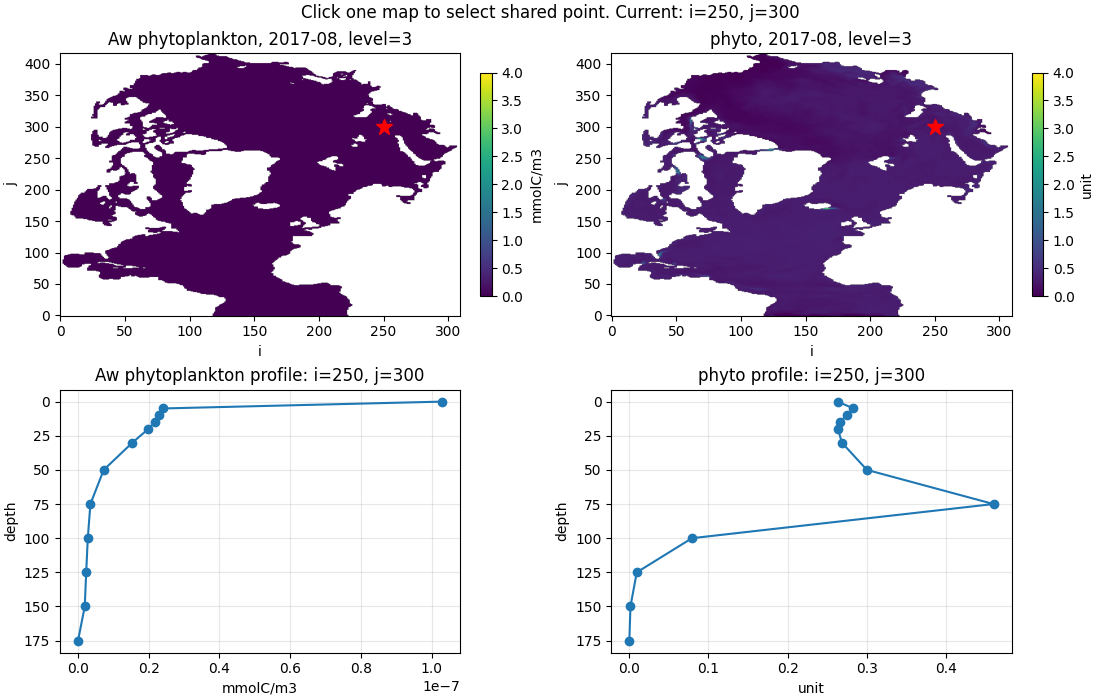

CancelledError: 

In [ ]:
selected_file = make_file_path(BIOEXP, SNAP_YEAR, SNAP_MONTH)
print(f'Selected file: {selected_file}')
if NC_INFO:
    inspect_nc(selected_file)

obs_point, phyto_point = await plot_linked_fields_from_click_ipympl(
    i=INITIAL_I,
    j=INITIAL_J,
    **prefix_kwargs('left_', obs_field_kwargs),
    **prefix_kwargs('right_', phyto_field_kwargs),
    **plot_common_kwargs,
)

print(f"{obs['var_name']} point: i={obs_point[0]}, j={obs_point[1]}")
print(f'SibCIOM point: i={phyto_point[0]}, j={phyto_point[1]}')


python_executable: /home/dina/miniforge3/bin/python
python_version: 3.12.11 | packaged by conda-forge | (main, Jun  4 2025, 14:45:31) [GCC 13.3.0]
platform: Linux-6.8.0-111-generic-x86_64-with-glibc2.35
ipython_shell: ZMQInteractiveShell
IPython: 9.11.0
matplotlib: 3.10.8
matplotlib_backend: widget
interactive_expected: True
ipywidgets: 8.1.8
ipympl: 0.10.0
jupyterlab: NOT INSTALLED
notebook: NOT INSTALLED
jupyter_server: NOT INSTALLED
jupyterlab_widgets: 3.0.16
widgetsnbextension: 4.0.15
MPLBACKEND_env: module://matplotlib_inline.backend_inline
canvas_type: Canvas
callback_id: 15


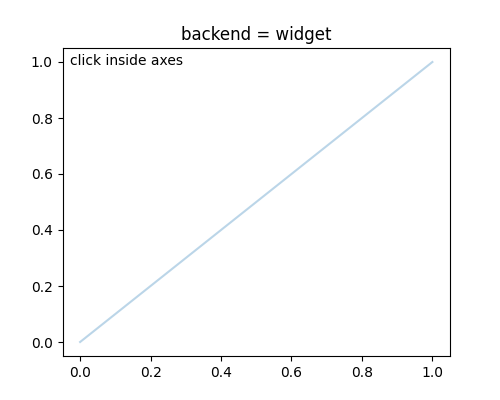

In [ ]:
from IPython import get_ipython
import sys
import os
import platform
from importlib.metadata import version, PackageNotFoundError

import IPython
import matplotlib
import ipywidgets

def pkg_version(name):
    try:
        return version(name)
    except PackageNotFoundError:
        return "NOT INSTALLED"

print("python_executable:", sys.executable)
print("python_version:", sys.version.replace("\n", " "))
print("platform:", platform.platform())

shell = get_ipython()
print("ipython_shell:", type(shell).__name__ if shell else None)
print("IPython:", IPython.__version__)

print("matplotlib:", matplotlib.__version__)
print("matplotlib_backend:", matplotlib.get_backend())
print("interactive_expected:", "inline" not in matplotlib.get_backend().lower() and "agg" not in matplotlib.get_backend().lower())

print("ipywidgets:", getattr(ipywidgets, "__version__", "unknown"))
print("ipympl:", pkg_version("ipympl"))
print("jupyterlab:", pkg_version("jupyterlab"))
print("notebook:", pkg_version("notebook"))
print("jupyter_server:", pkg_version("jupyter_server"))
print("jupyterlab_widgets:", pkg_version("jupyterlab_widgets"))
print("widgetsnbextension:", pkg_version("widgetsnbextension"))

print("MPLBACKEND_env:", os.environ.get("MPLBACKEND"))
from IPython import get_ipython
get_ipython().run_line_magic("matplotlib", "widget")  # или "notebook", если widget не работает

import matplotlib
import matplotlib.pyplot as plt

clicks = []

fig, ax = plt.subplots(figsize=(5, 4))
ax.set_title(f"backend = {matplotlib.get_backend()}")
ax.plot([0, 1], [0, 1], alpha=0.3)

marker, = ax.plot([], [], "r*", ms=14)
text = ax.text(0.02, 0.98, "click inside axes", transform=ax.transAxes, va="top")

def on_click(event):
    if event.inaxes is not ax or event.xdata is None or event.ydata is None:
        return
    clicks.append((event.xdata, event.ydata))
    marker.set_data([event.xdata], [event.ydata])
    text.set_text(f"last click: ({event.xdata:.2f}, {event.ydata:.2f})\ncount={len(clicks)}")
    fig.canvas.draw_idle()
    print("CLICK:", event.xdata, event.ydata)

cid = fig.canvas.mpl_connect("button_press_event", on_click)

print("canvas_type:", type(fig.canvas).__name__)
print("callback_id:", cid)

plt.show()